In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ES 

In [5]:
df = pd.read_csv('Auto_sales.csv', sep=';', decimal=',', parse_dates=['Date'],index_col='Date')

df = df.dropna()

In [6]:
Xhat1 = df.Auto_sales[0]
alpha1 = 0.9

C:\Users\mrosk\AppData\Local\Temp\ipykernel_1548\3884524205.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Xhat1 = df.Auto_sales[0]


In [7]:
ses_0_9 = ES(df.iloc[:-5,:].Auto_sales, initialization_method='known',initial_level=Xhat1).fit(smoothing_level=alpha1,optimized =False)

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [8]:
df['ses_0_9_fit'] = ses_0_9.fittedvalues

In [9]:
alpha2 = 0.2
ses_0_2 = ES(df.iloc[:-5,:].Auto_sales, initialization_method='known',initial_level=Xhat1).fit(smoothing_level=alpha2,optimized=False)

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
df['ses_0_2_fit'] = ses_0_2.fittedvalues

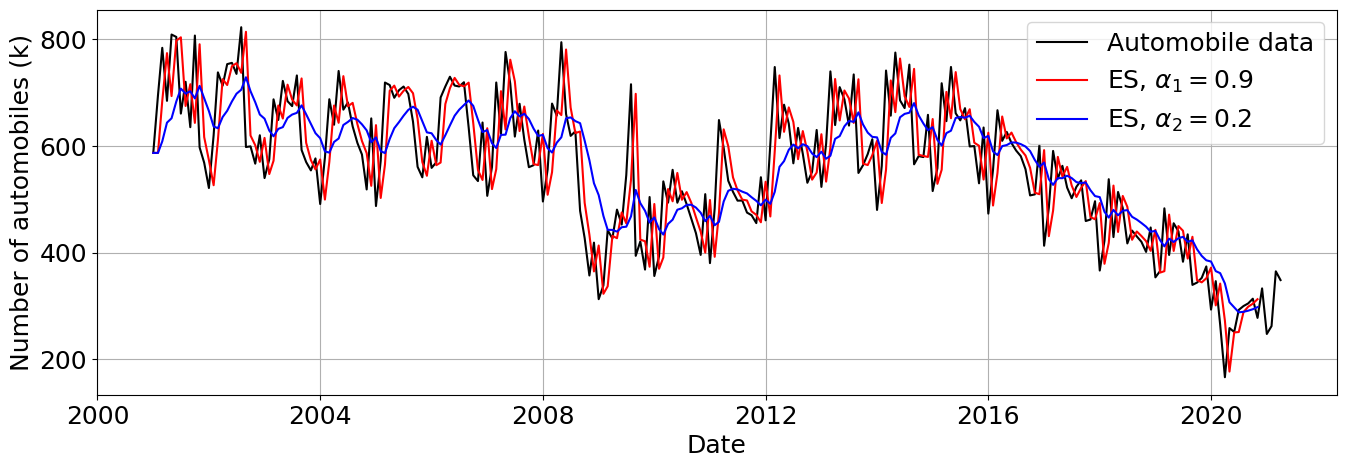

In [13]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(16, 5), dpi=100)

plt.plot(df.index,df.Auto_sales, color='k',label="Automobile data")

plt.plot(df.index,df.ses_0_9_fit,color='r', label = r'ES, $\alpha_{1}=0.9$')

plt.plot(df.index,df.ses_0_2_fit,color='b',label=r'ES, $\alpha_{2}=0.2$')

plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.legend()
plt.show()


In [14]:
h = 5

In [15]:
df.ses_0_9_fit.iloc[-h:] = ses_0_9.forecast(steps=h)
df.ses_0_2_fit.iloc[-h:] = ses_0_2.forecast(steps=h)

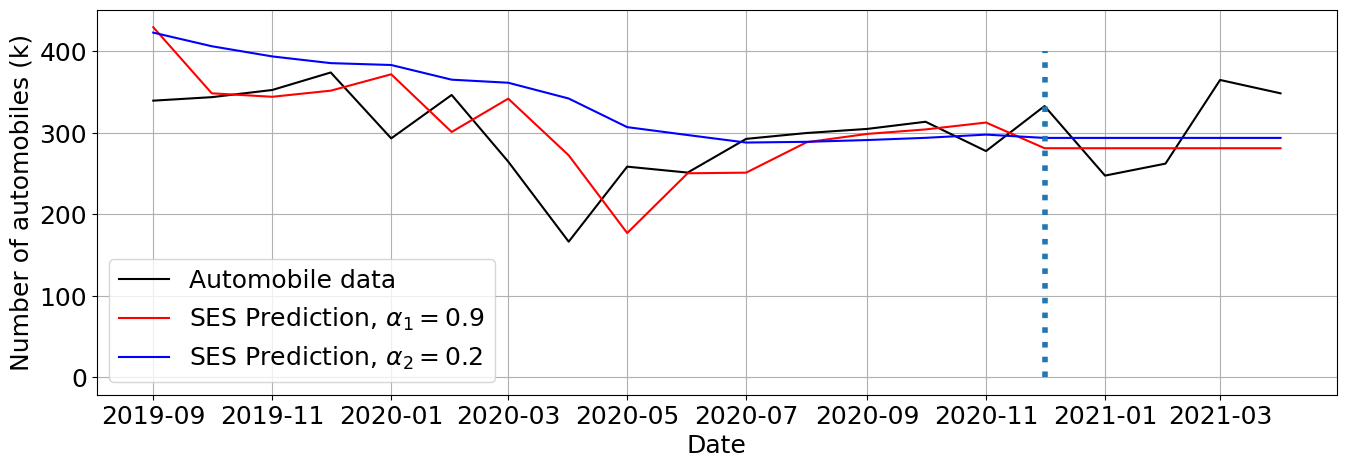

In [17]:
plt.figure(figsize=(16, 5), dpi=100)
# last 20 observations
plt.plot(df.Auto_sales[-20:], \
    color='k', label='Automobile data')

# SES forecasts with alpha=0.9
plt.plot(df.ses_0_9_fit[-20:], color='r', \
    label=r'SES Prediction, $\alpha_{1}=0.9$')

# SES forecats with alpha=0.2
plt.plot(df.ses_0_2_fit[-20:], color='b', \
    label=r'SES Prediction, $\alpha_{2}=0.2$')

# indicate forcasting start point
plt.vlines(df.index[-h], 0, 400, \
    linestyles='dotted', lw=4)

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.legend()
plt.show()

In [18]:
ses_ols = ES(df.Auto_sales).fit(method='ls')

print(ses_ols.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:               Auto_sales   No. Observations:                  244
Model:             ExponentialSmoothing   SSE                        1445784.226
Optimized:                         True   AIC                           2123.627
Trend:                             None   BIC                           2130.621
Seasonal:                          None   AICC                          2123.794
Seasonal Periods:                  None   Date:                 Mon, 21 Oct 2024
Box-Cox:                          False   Time:                         11:02:35
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5406163                alpha                 True
initial_level              649.984

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


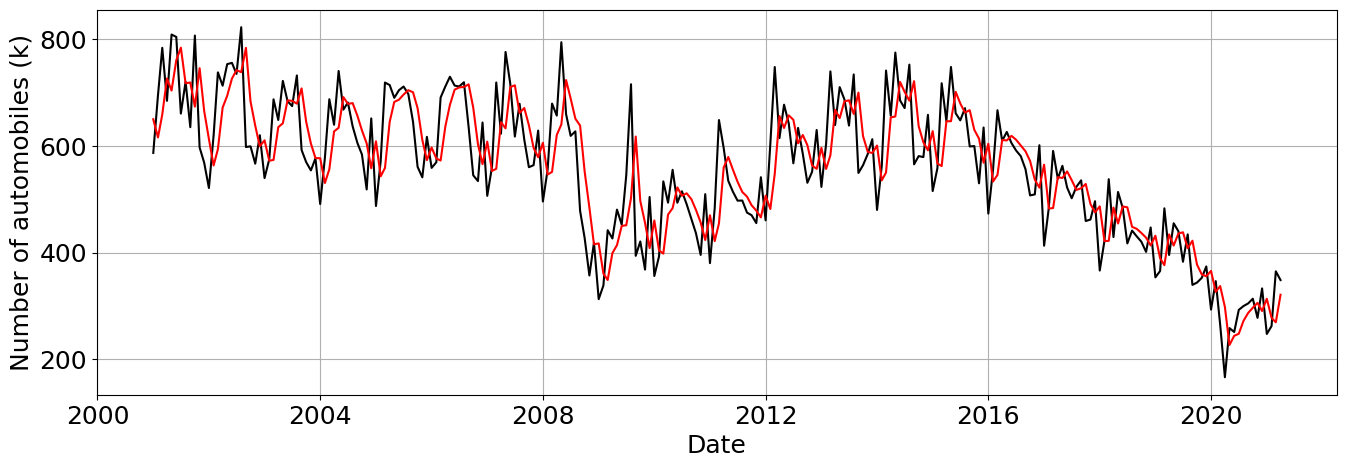

In [19]:
# %% plot the fitted series
plt.figure(figsize=(16, 5), dpi=100)

# observed data
plt.plot(df.index, df.Auto_sales, color='k')

# fitted data
plt.plot(df.index, ses_ols.fittedvalues, color='r')

# artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.show()
